
<div style="background:#0B1220; padding:26px; border-radius:16px; border:1px solid rgba(255,255,255,0.12);">
  <h1 style="color:#E6EDF3; margin:0; font-size:34px; text-align:center;">
    Data Center Interoperability, Performance, and Energy Crisis Analytics
  </h1>
  <p style="color:#C9D1D9; margin:10px 0 0 0; font-size:14px; text-align:center;">
    Operational metrics, risk signals, and mitigation protocols for modern fleets
  </p>
  <p style="color:#C9D1D9; margin:6px 0 0 0; font-size:13px; text-align:center; opacity:0.92;">
    By DaScient
  </p>
</div>



## Scope

This notebook provides a functional, actionable framework to examine:

- interoperability performance metrics across heterogeneous data center stacks  
- energy and grid impact metrics under scale pressure  
- mitigation protocols that reduce risk, cost, and carbon while preserving SLOs  

It runs end to end on synthetic data by default and includes clean adapters for plugging in real telemetry exports.

Deliverables produced by this notebook:

- a metric dictionary with clear definitions  
- computed fleet level and site level KPIs  
- high fidelity visualizations suitable for executive and engineering reviews  
- mitigation recommendations tied directly to observed signals  



## Contents

1. Definitions: interoperability, performance, energy, and grid metrics  
2. Data model: telemetry schema for multi site fleets  
3. Synthetic fleet generator (replaceable with real data ingestion)  
4. KPI computation: PUE, CUE, WUE, SLO, Joules per request, carbon per request  
5. Interoperability analysis: portability, interface drift, observability coverage  
6. Bottleneck diagnosis: queueing, saturation, thermal throttling, power caps  
7. Mitigation protocols: operational playbooks and decision rules  
8. Scenario analysis: demand response and carbon aware scheduling  
9. Reporting: run export (CSV and JSON)  



## 1. Definitions

### Interoperability performance metrics

Interoperability is measured by how efficiently workloads and controls move across:

- vendors (compute, network, storage, accelerators)  
- orchestration layers (Kubernetes, batch, serverless)  
- observability stacks (metrics, logs, traces)  
- identity and policy planes (authn, authz, secrets, attestations)  

Operational interoperability metrics:

- Portability lead time: hours to migrate a workload between sites or vendors  
- Interface drift rate: frequency of breaking changes across APIs, CLIs, config contracts  
- Telemetry coverage: fraction of critical components emitting standard metrics and traces  
- Control plane consistency: policy parity and network policy parity across sites  
- SLO preservation under migration: delta in latency and error rate after a move  

### Energy and grid metrics

Core facility metrics:

- PUE (Power Usage Effectiveness) = facility power / IT power  
- CUE (Carbon Usage Effectiveness) = CO2e / IT energy  
- WUE (Water Usage Effectiveness) = water / IT energy  

Workload normalized metrics:

- Joules per request (or Joules per token, Joules per inference)  
- CO2e per request = Joules per request times grid carbon intensity  
- kWh per useful work unit (domain specific)  

Grid stress signals:

- peak coincidence factor: how often load peaks during grid peak hours  
- demand response readiness: percent of load that can shed or shift within minutes  
- carbon aware schedulability: percent of workload that can move in time or geography  

The aim is not a single number. The aim is a coordinated set of signals with decision rules.



## 2. Environment and plotting standards

Notes:

- The notebook uses matplotlib only.  
- Figures are configured for high fidelity output.  
- Colors are not specified explicitly, so matplotlib defaults apply.  


In [1]:

import os, json, time, math, hashlib, random
from dataclasses import dataclass, asdict
from typing import Dict, Any, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 11

def set_seed(seed: int = 7) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(7)



## 3. Data model: telemetry schema for multi site fleets

A practical fleet telemetry table can be represented with columns:

- time_utc (timestamp)  
- site (data center identifier)  
- region (grid region identifier)  
- workload (service or job family)  
- it_kw (IT load in kW)  
- facility_kw (total site power in kW)  
- water_lph (water liters per hour)  
- carbon_g_per_kwh (grid carbon intensity)  
- rps (requests per second)  
- p95_ms (p95 latency)  
- error_rate (fraction)  
- cpu_util, gpu_util (fraction)  
- temp_c (inlet or hotspot proxy)  
- throttling_rate (fraction)  
- power_capping_rate (fraction)  
- telemetry_coverage (0 to 1)  
- api_drift_events (count per window)  
- migration_events (count per window)  
- migration_p95_delta_ms (latency delta after migrations)  

You can ingest real exports (Prometheus, OpenTelemetry, billing, CMDB) by mapping to these fields.



## 4. Synthetic fleet generator

The generator creates:

- multiple sites with different cooling and grid intensities  
- heterogeneous workloads with different efficiency profiles  
- realistic correlations: higher utilization raises temperature, which can raise throttling  
- demand patterns with peak hours  

Replace this generator with your real ingestion function later.


In [2]:

@dataclass
class FleetConfig:
    n_days: int = 30
    freq_min: int = 30
    sites: Tuple[str, ...] = ("SLC-1", "IAD-2", "DFW-1", "PDX-1")
    regions: Tuple[str, ...] = ("RockyMountain", "PJM", "ERCOT", "PNW")
    workloads: Tuple[str, ...] = ("Search", "Ads", "Training", "Inference", "Storage")
    seed: int = 7

cfg = FleetConfig()

def make_time_index(n_days: int, freq_min: int) -> pd.DatetimeIndex:
    start = pd.Timestamp.utcnow().floor("D") - pd.Timedelta(days=n_days)
    return pd.date_range(start=start, periods=int(n_days * 24 * 60 / freq_min), freq=f"{freq_min}min", tz="UTC")

def diurnal_profile(ts: pd.DatetimeIndex) -> np.ndarray:
    hour = ts.hour + ts.minute / 60.0
    return 0.65 + 0.35 * np.sin((hour - 7) / 24.0 * 2 * np.pi)

def generate_fleet(cfg: FleetConfig) -> pd.DataFrame:
    set_seed(cfg.seed)
    ts = make_time_index(cfg.n_days, cfg.freq_min)
    diurnal = diurnal_profile(ts)

    site_params = {
        "SLC-1": {"base_pue": 1.22, "pue_var": 0.06, "water_lph_per_it_kw": 0.15, "grid_gpkwh": 420},
        "IAD-2": {"base_pue": 1.30, "pue_var": 0.07, "water_lph_per_it_kw": 0.10, "grid_gpkwh": 350},
        "DFW-1": {"base_pue": 1.35, "pue_var": 0.09, "water_lph_per_it_kw": 0.22, "grid_gpkwh": 520},
        "PDX-1": {"base_pue": 1.18, "pue_var": 0.05, "water_lph_per_it_kw": 0.08, "grid_gpkwh": 160},
    }

    workload_params = {
        "Search": {"rps_per_it_kw": 38, "p95_base": 46, "err_base": 0.004, "gpu_frac": 0.05},
        "Ads": {"rps_per_it_kw": 32, "p95_base": 55, "err_base": 0.006, "gpu_frac": 0.10},
        "Training": {"rps_per_it_kw": 0.15, "p95_base": 0,  "err_base": 0.002, "gpu_frac": 0.80},
        "Inference": {"rps_per_it_kw": 11, "p95_base": 85, "err_base": 0.008, "gpu_frac": 0.55},
        "Storage": {"rps_per_it_kw": 5, "p95_base": 20, "err_base": 0.003, "gpu_frac": 0.00},
    }

    rows = []
    for site, region in zip(cfg.sites, cfg.regions):
        sp = site_params[site]
        base_it_kw = {"SLC-1": 8200, "IAD-2": 9800, "DFW-1": 7600, "PDX-1": 6900}[site]

        for wl in cfg.workloads:
            wp = workload_params[wl]
            wl_share = {"Search": 0.28, "Ads": 0.18, "Training": 0.20, "Inference": 0.22, "Storage": 0.12}[wl]

            it_kw = base_it_kw * wl_share * (0.75 + 0.45 * diurnal) * (1 + 0.06 * np.random.randn(len(ts)))
            it_kw = np.clip(it_kw, 0, None)

            pue = sp["base_pue"] + sp["pue_var"] * np.sin(np.linspace(0, 6*np.pi, len(ts))) + 0.015*np.random.randn(len(ts))
            pue = np.clip(pue, 1.05, 1.8)

            facility_kw = it_kw * pue
            water_lph = it_kw * sp["water_lph_per_it_kw"] * (0.9 + 0.2*np.random.rand(len(ts)))

            carbon = sp["grid_gpkwh"] * (0.85 + 0.25 * (1 - diurnal)) * (0.95 + 0.08*np.random.randn(len(ts)))
            carbon = np.clip(carbon, 40, 900)

            cpu_util = np.clip(0.35 + 0.45*(it_kw / (base_it_kw * wl_share + 1e-9)) + 0.08*np.random.randn(len(ts)), 0, 1)
            gpu_util = np.clip(wp["gpu_frac"] * (0.55 + 0.55*(it_kw / (base_it_kw * wl_share + 1e-9))) + 0.12*np.random.randn(len(ts)), 0, 1)

            temp_c = np.clip(22 + 10*cpu_util + 6*gpu_util + 3*(pue - sp["base_pue"]) + 1.2*np.random.randn(len(ts)), 16, 45)
            throttling = np.clip((temp_c - 32) / 14, 0, 1) * (0.35 + 0.65*gpu_util)

            power_cap = np.clip((facility_kw - np.quantile(facility_kw, 0.92)) / (np.quantile(facility_kw, 0.98) - np.quantile(facility_kw, 0.92) + 1e-9), 0, 1)
            power_cap = np.clip(power_cap + 0.06*np.random.randn(len(ts)), 0, 1)

            rps = np.clip(wp["rps_per_it_kw"] * it_kw * (1 - 0.12*throttling) * (0.95 + 0.06*np.random.randn(len(ts))), 0, None)

            p95 = wp["p95_base"] + 55*throttling + 30*power_cap + 12*np.maximum(cpu_util - 0.85, 0) + 4*np.random.randn(len(ts))
            p95 = np.clip(p95, 1, None) if wp["p95_base"] > 0 else np.zeros(len(ts))

            err = np.clip(wp["err_base"] + 0.020*throttling + 0.012*power_cap + 0.010*np.maximum(cpu_util - 0.90, 0) + 0.002*np.random.rand(len(ts)), 0, 0.25)

            telemetry_coverage = np.clip(0.88 + 0.10*np.random.randn(len(ts)) - 0.12*(wl == "Training") + 0.05*(site == "PDX-1"), 0.3, 1.0)
            api_drift = np.random.poisson(lam=0.05 + 0.10*(wl == "Inference") + 0.06*(site == "DFW-1"), size=len(ts))

            migrations = np.random.poisson(lam=0.02 + 0.03*(wl in ["Inference","Search"]) + 0.02*(site == "IAD-2"), size=len(ts))
            mig_p95_delta = np.where(migrations > 0, np.clip(15 + 25*np.random.randn(len(ts)), -10, 140), 0.0)

            for i in range(len(ts)):
                rows.append({
                    "time_utc": ts[i],
                    "site": site,
                    "region": region,
                    "workload": wl,
                    "it_kw": float(it_kw[i]),
                    "facility_kw": float(facility_kw[i]),
                    "water_lph": float(water_lph[i]),
                    "carbon_g_per_kwh": float(carbon[i]),
                    "rps": float(rps[i]),
                    "p95_ms": float(p95[i]),
                    "error_rate": float(err[i]),
                    "cpu_util": float(cpu_util[i]),
                    "gpu_util": float(gpu_util[i]),
                    "temp_c": float(temp_c[i]),
                    "throttling_rate": float(throttling[i]),
                    "power_capping_rate": float(power_cap[i]),
                    "telemetry_coverage": float(telemetry_coverage[i]),
                    "api_drift_events": int(api_drift[i]),
                    "migration_events": int(migrations[i]),
                    "migration_p95_delta_ms": float(mig_p95_delta[i]),
                })

    return pd.DataFrame(rows)

df = generate_fleet(cfg)
df.head(), df.shape


(                   time_utc   site         region workload        it_kw  \
 0 2026-01-28 00:00:00+00:00  SLC-1  RockyMountain   Search  2251.636569   
 1 2026-01-28 00:30:00+00:00  SLC-1  RockyMountain   Search  1978.161255   
 2 2026-01-28 01:00:00+00:00  SLC-1  RockyMountain   Search  2035.961356   
 3 2026-01-28 01:30:00+00:00  SLC-1  RockyMountain   Search  2084.812761   
 4 2026-01-28 02:00:00+00:00  SLC-1  RockyMountain   Search  1947.515038   
 
    facility_kw   water_lph  carbon_g_per_kwh           rps     p95_ms  \
 0  2656.358500  340.883531        412.561173  87795.704973  53.877556   
 1  2369.370356  304.553016        399.289732  70835.268662  48.877784   
 2  2500.165775  276.617462        410.498775  71494.366125  44.543321   
 3  2573.157279  335.453036        451.841267  81028.447553  42.142313   
 4  2344.090582  301.913656        482.833423  76145.973892  45.821234   
 
    error_rate  cpu_util  gpu_util     temp_c  throttling_rate  \
 0    0.005322  0.827512  0.12


## 5. KPI computation

We compute site and fleet KPIs:

Facility and grid:

- PUE (site level, time series)  
- IT energy (kWh) and facility energy (kWh)  
- CO2e (kg) using carbon intensity  
- CUE proxy (kg CO2e per kWh IT)  
- WUE proxy (L per kWh IT)  

Workload normalized:

- Joules per request  
- CO2e per request  
- Errors per million requests  
- SLO compliance rate (p95 below target, error below target)  

Interoperability:

- telemetry coverage percentiles  
- drift events per day  
- migration frequency and SLO delta under migration  


In [3]:

def add_derived_metrics(df: pd.DataFrame, freq_min: int) -> pd.DataFrame:
    out = df.copy()
    hours = freq_min / 60.0

    out["it_kwh"] = out["it_kw"] * hours
    out["facility_kwh"] = out["facility_kw"] * hours
    out["pue"] = out["facility_kw"] / np.maximum(out["it_kw"], 1e-9)

    out["co2e_kg"] = out["facility_kwh"] * (out["carbon_g_per_kwh"] / 1000.0)
    out["water_l"] = out["water_lph"] * hours

    out["requests"] = out["rps"] * (hours * 3600.0)
    out["joules"] = out["facility_kwh"] * 3.6e6
    out["joules_per_request"] = out["joules"] / np.maximum(out["requests"], 1.0)

    out["co2e_g_per_request"] = (out["co2e_kg"] * 1000.0) / np.maximum(out["requests"], 1.0)
    out["errors_per_million"] = (out["error_rate"] * out["requests"]) / np.maximum(out["requests"], 1.0) * 1e6

    return out

dfm = add_derived_metrics(df, cfg.freq_min)

SLO_P95_MS = 120.0
SLO_ERR = 0.01
dfm["slo_ok"] = ((dfm["p95_ms"] <= SLO_P95_MS) | (dfm["p95_ms"] == 0.0)) & (dfm["error_rate"] <= SLO_ERR)

dfm[["pue","co2e_kg","water_l","joules_per_request","co2e_g_per_request","slo_ok"]].describe().T


,count,mean,std,min,25%,50%,75%,max
pue,28800.0,1.262434,0.083912,1.085895,1.197642,1.253761,1.321884,1.494248
co2e_kg,28800.0,352.393340,177.166892,45.813805,194.744586,368.805154,477.466797,973.156432
water_l,28800.0,115.414913,55.671907,24.323365,69.766425,107.421634,150.641329,354.810732
joules_per_request,28800.0,1924.521814,3637.657295,25.491445,39.799420,122.089963,282.241991,12468.783875
co2e_g_per_request,28800.0,0.175205,0.364540,0.000827,0.003919,0.010189,0.031211,1.929402



## 6. Visualizations

This section generates a professional set of visuals:

- fleet power and carbon over time  
- site PUE distributions  
- carbon intensity versus facility load  
- Joules per request by workload  
- SLO compliance versus throttling and power capping  
- interoperability signals (telemetry coverage, drift, migration impact)  


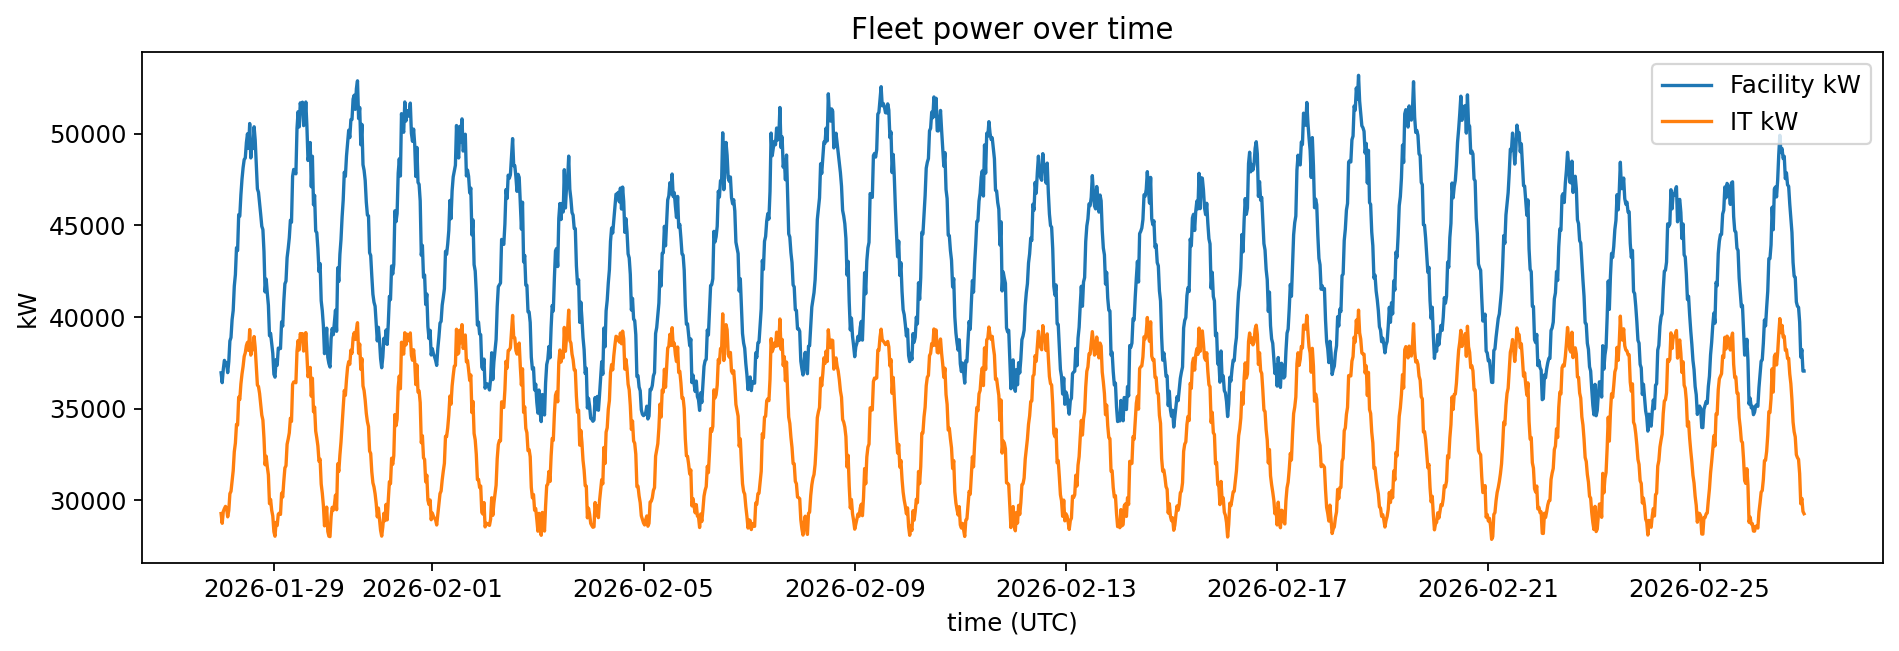

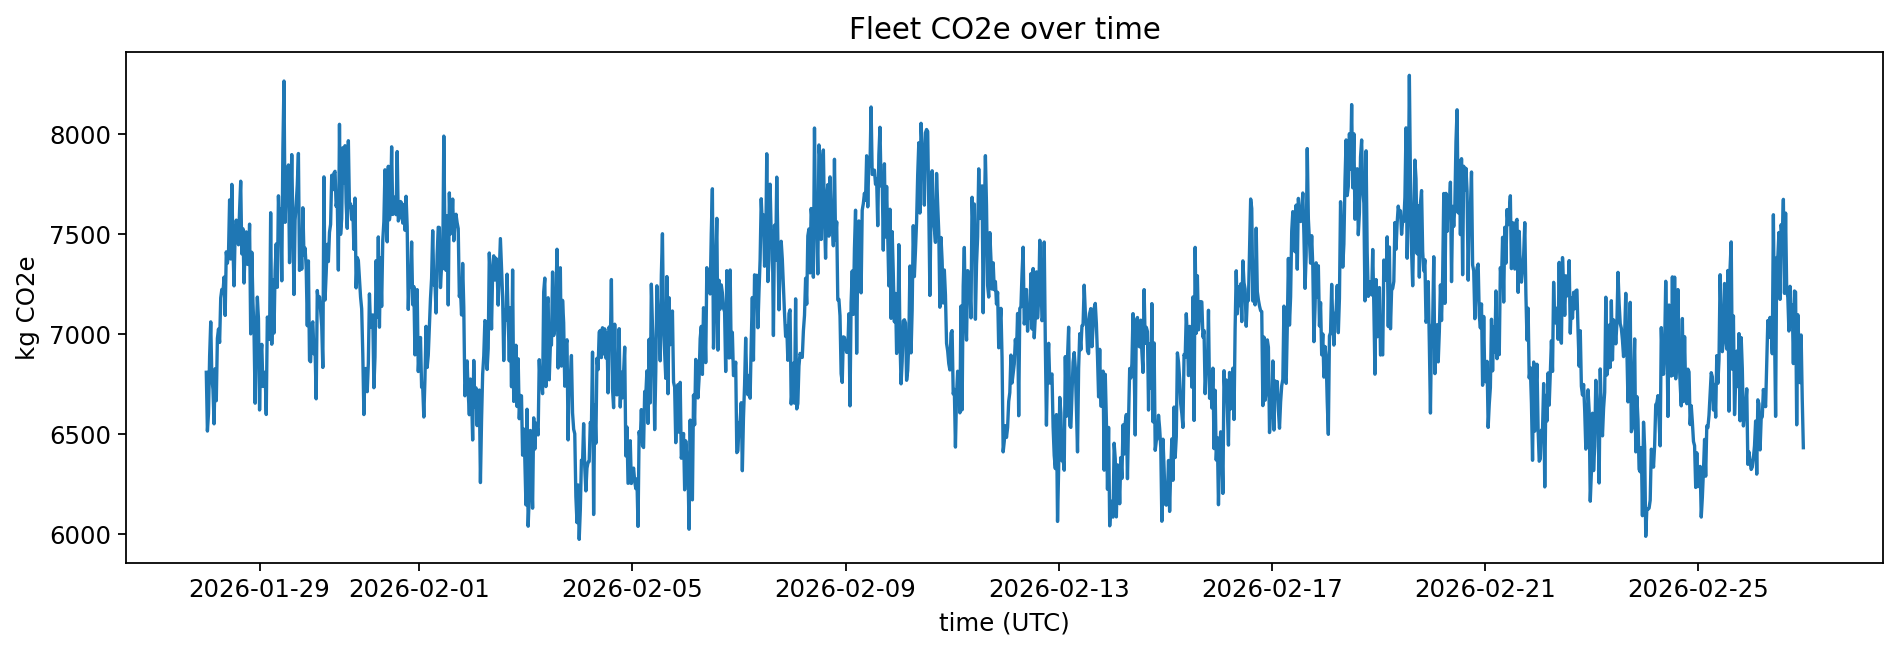

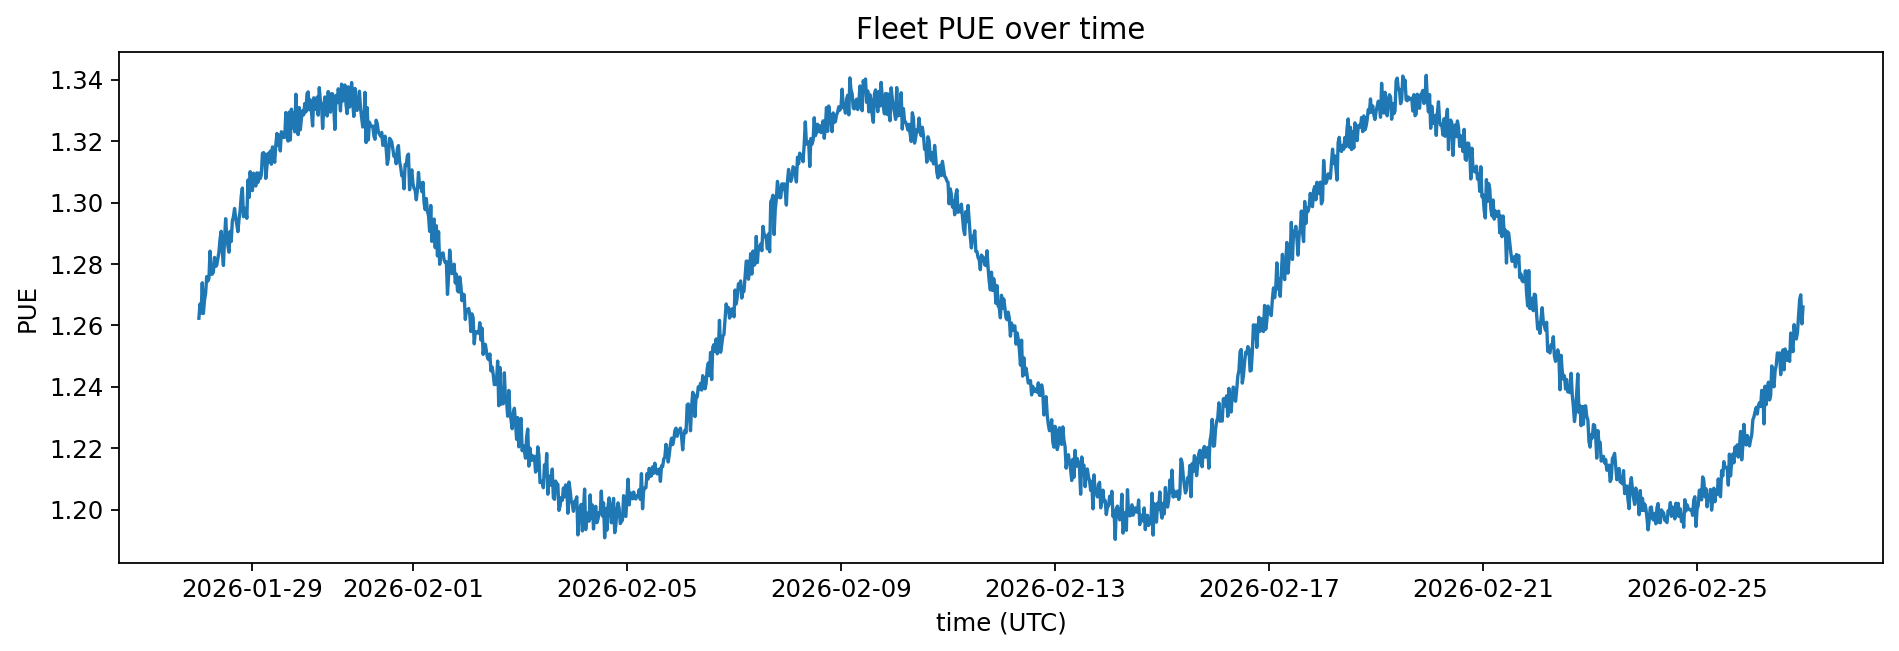

In [4]:

fleet_ts = dfm.groupby("time_utc", as_index=False).agg(
    it_kw=("it_kw","sum"),
    facility_kw=("facility_kw","sum"),
    co2e_kg=("co2e_kg","sum"),
    requests=("requests","sum"),
)

fleet_ts["pue"] = fleet_ts["facility_kw"] / np.maximum(fleet_ts["it_kw"], 1e-9)
fleet_ts["co2e_g_per_request"] = (fleet_ts["co2e_kg"] * 1000.0) / np.maximum(fleet_ts["requests"], 1.0)

plt.figure(figsize=(12,4.2))
plt.plot(fleet_ts["time_utc"], fleet_ts["facility_kw"], label="Facility kW")
plt.plot(fleet_ts["time_utc"], fleet_ts["it_kw"], label="IT kW")
plt.title("Fleet power over time")
plt.ylabel("kW")
plt.xlabel("time (UTC)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4.2))
plt.plot(fleet_ts["time_utc"], fleet_ts["co2e_kg"])
plt.title("Fleet CO2e over time")
plt.ylabel("kg CO2e")
plt.xlabel("time (UTC)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4.2))
plt.plot(fleet_ts["time_utc"], fleet_ts["pue"])
plt.title("Fleet PUE over time")
plt.ylabel("PUE")
plt.xlabel("time (UTC)")
plt.tight_layout()
plt.show()


/var/folders/y3/n46q7k254pv9w9knmxbn1v540000gn/T/ipykernel_18412/420378506.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([site_pue.loc[site_pue["site"]==s, "pue"].values for s in sites], labels=sites, showfliers=False)


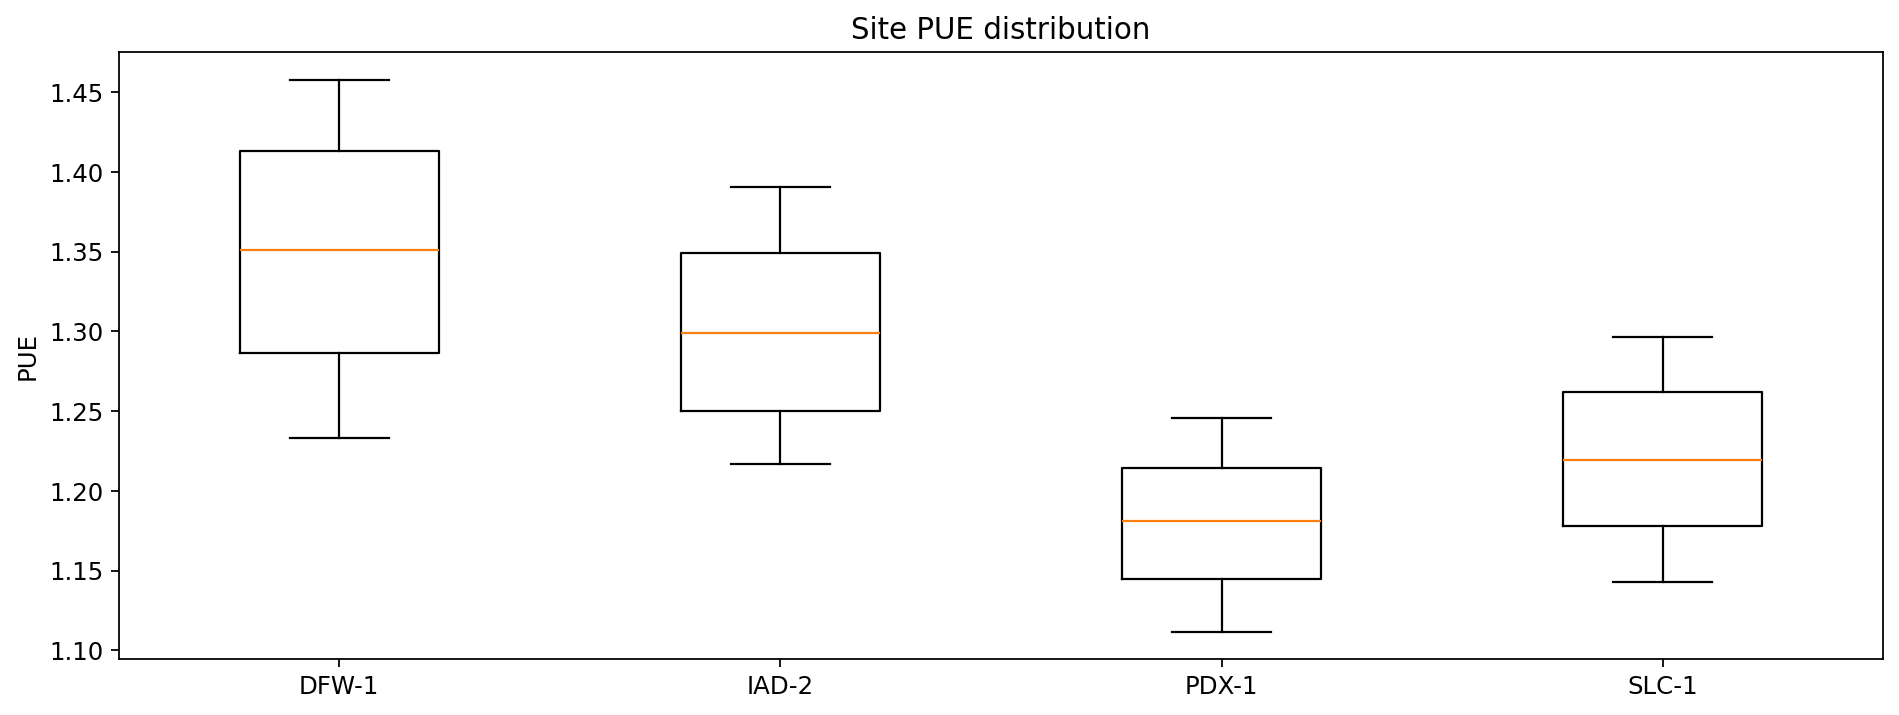

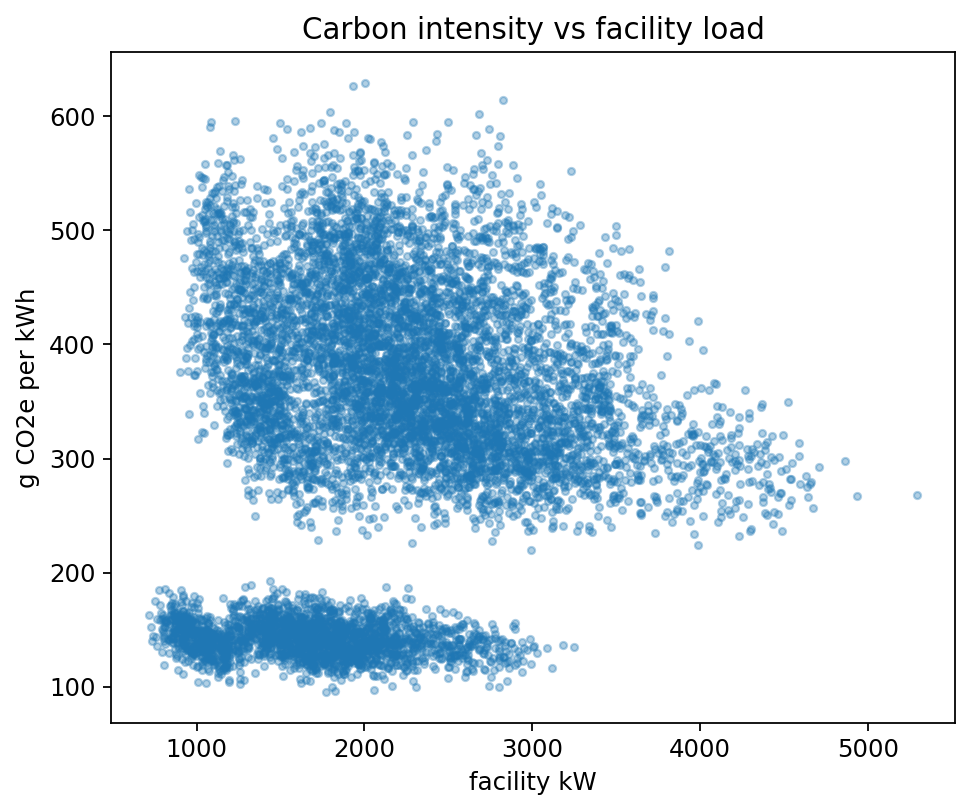

In [5]:

site_pue = dfm.groupby(["site","time_utc"], as_index=False).agg(
    it_kw=("it_kw","sum"),
    facility_kw=("facility_kw","sum"),
)
site_pue["pue"] = site_pue["facility_kw"] / np.maximum(site_pue["it_kw"], 1e-9)

sites = list(site_pue["site"].unique())
plt.figure(figsize=(12,4.6))
plt.boxplot([site_pue.loc[site_pue["site"]==s, "pue"].values for s in sites], labels=sites, showfliers=False)
plt.title("Site PUE distribution")
plt.ylabel("PUE")
plt.tight_layout()
plt.show()

sample = dfm.sample(n=min(9000, len(dfm)), random_state=7)

plt.figure(figsize=(6.2,5.2))
plt.scatter(sample["facility_kw"], sample["carbon_g_per_kwh"], alpha=0.35, s=10)
plt.title("Carbon intensity vs facility load")
plt.xlabel("facility kW")
plt.ylabel("g CO2e per kWh")
plt.tight_layout()
plt.show()


/var/folders/y3/n46q7k254pv9w9knmxbn1v540000gn/T/ipykernel_18412/4066474617.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dfm.loc[dfm["workload"]==w, "joules_per_request"].values for w in wls], labels=wls, showfliers=False)


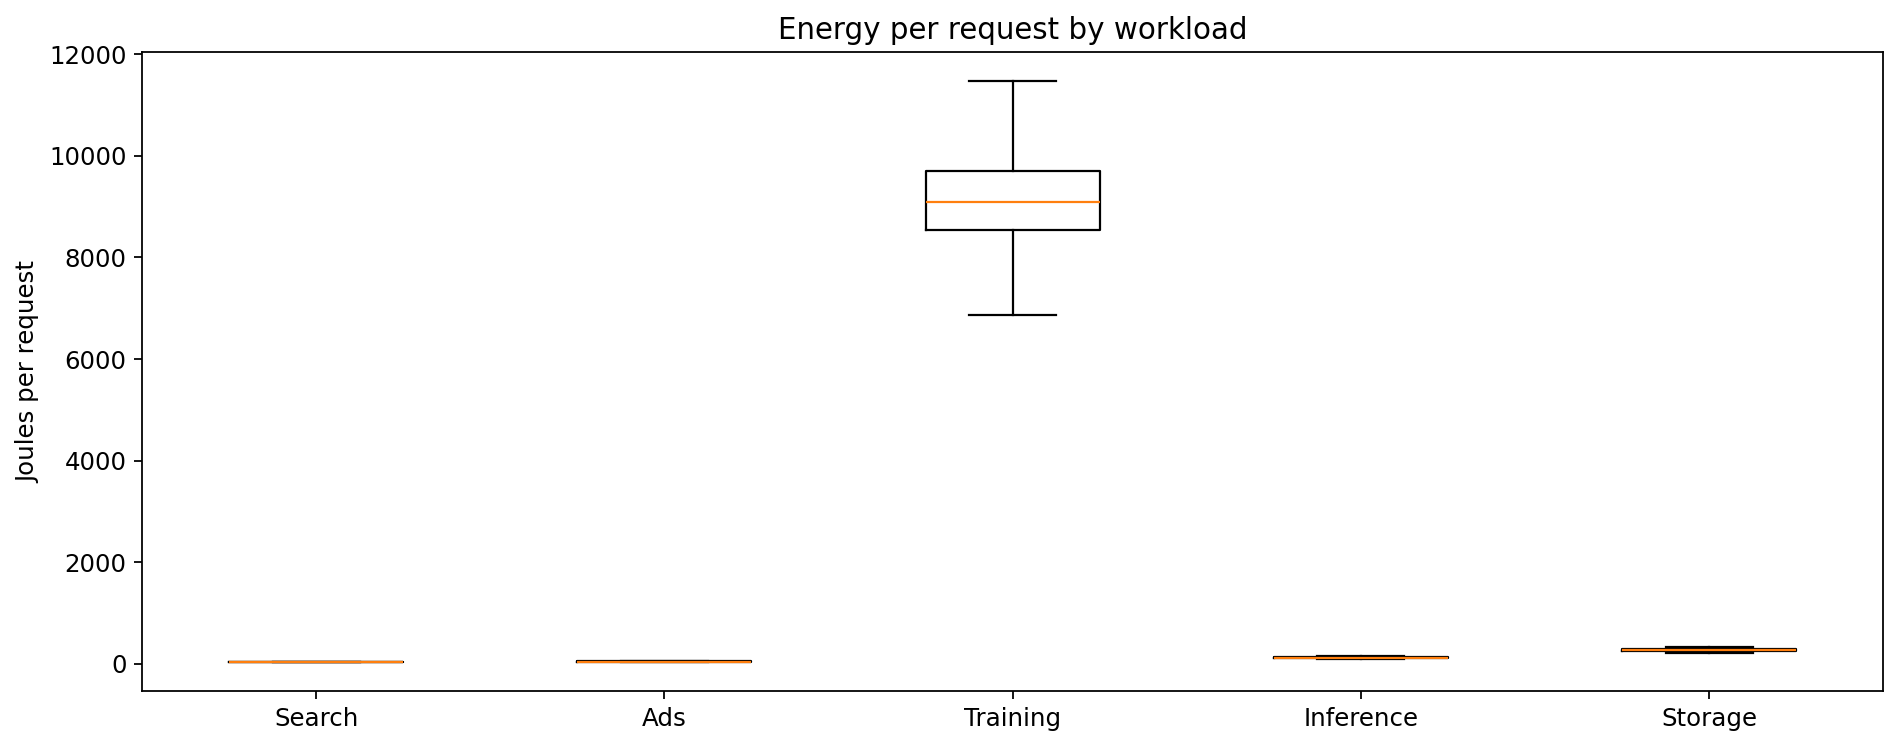

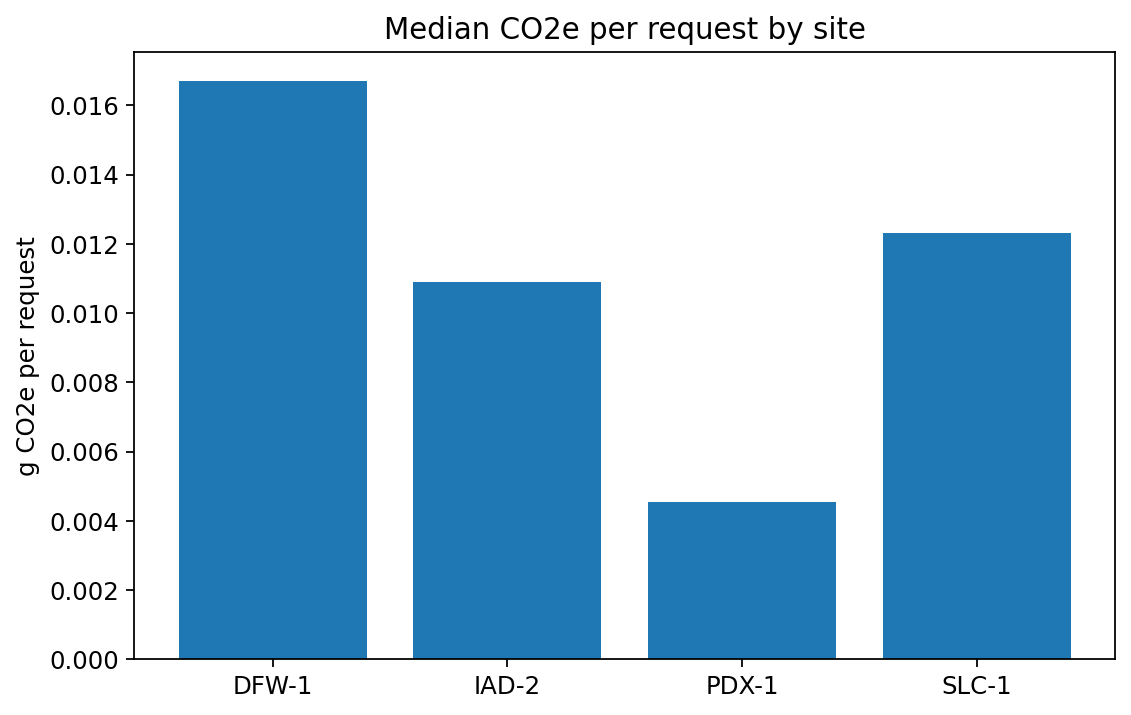

In [6]:

wls = list(dfm["workload"].unique())
plt.figure(figsize=(12,4.8))
plt.boxplot([dfm.loc[dfm["workload"]==w, "joules_per_request"].values for w in wls], labels=wls, showfliers=False)
plt.title("Energy per request by workload")
plt.ylabel("Joules per request")
plt.tight_layout()
plt.show()

site_co2 = dfm.groupby("site", as_index=False).agg(median_g=("co2e_g_per_request","median"))
plt.figure(figsize=(7.2,4.6))
plt.bar(site_co2["site"], site_co2["median_g"])
plt.title("Median CO2e per request by site")
plt.ylabel("g CO2e per request")
plt.tight_layout()
plt.show()


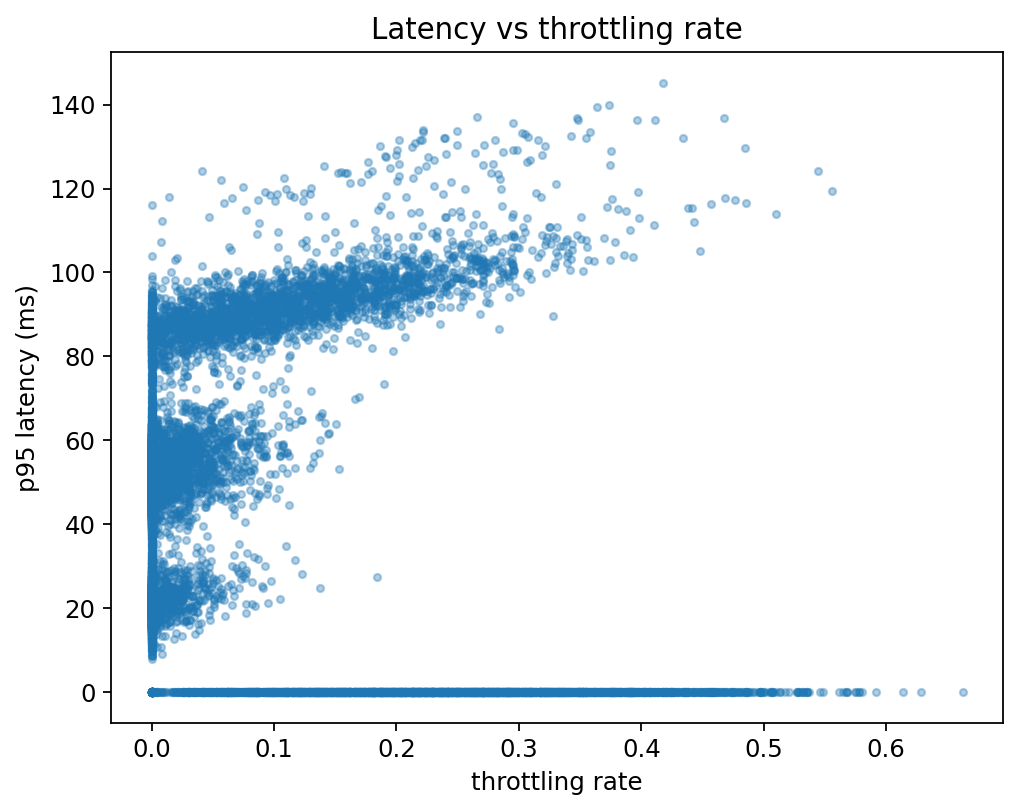

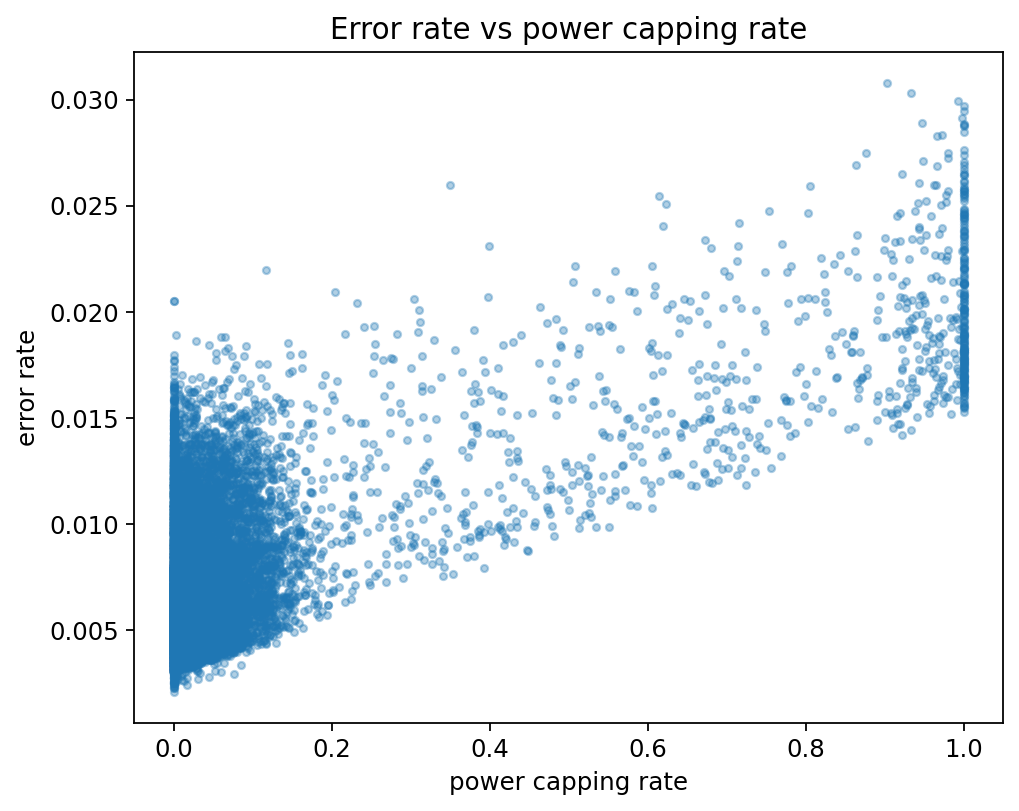

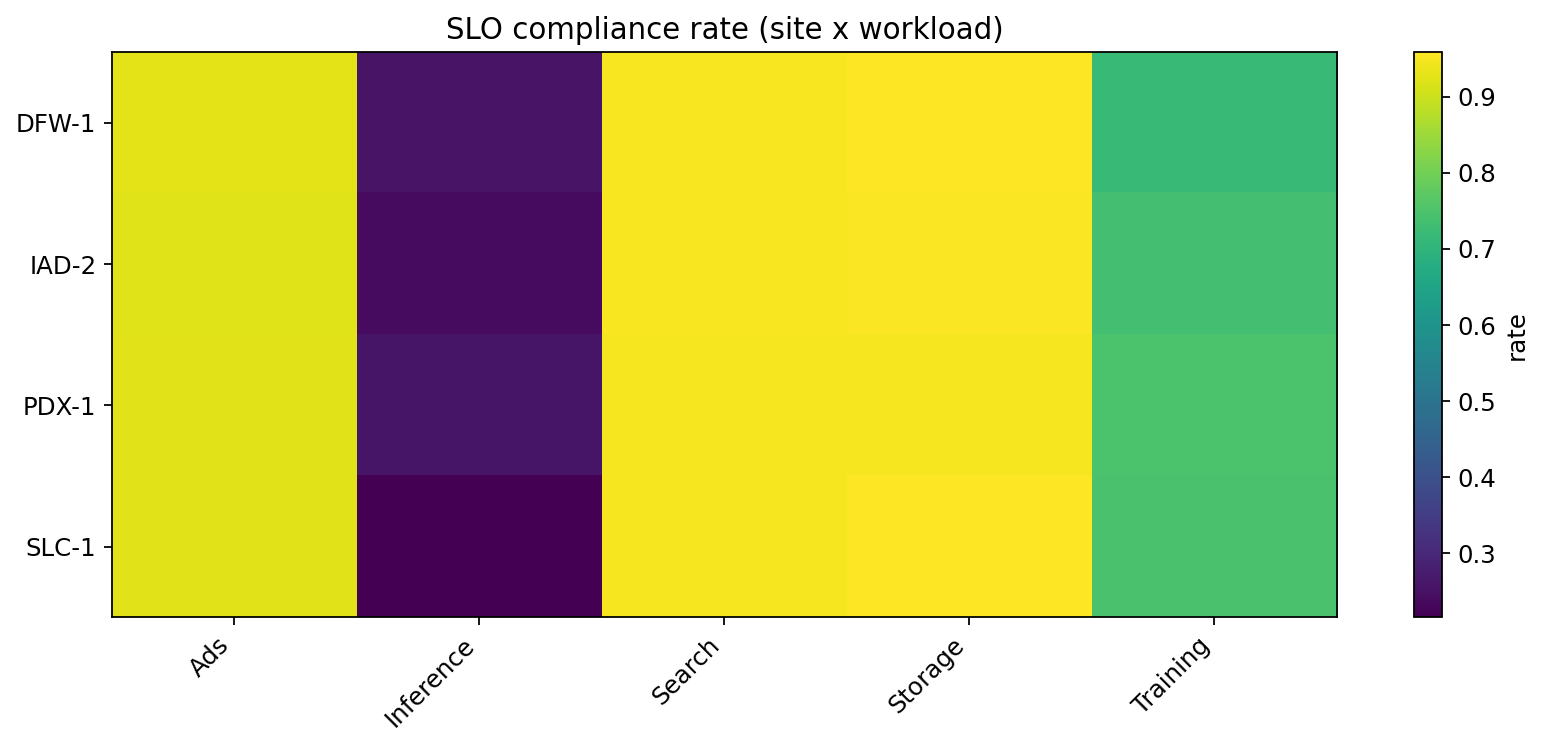

,site,workload,slo_ok_rate,mean_p95,mean_err,mean_throttle,mean_cap
16,SLC-1,Inference,0.215972,93.466619,0.012176,0.113213,0.067200
6,IAD-2,Inference,0.238889,93.519061,0.012169,0.112219,0.067460
1,DFW-1,Inference,0.255556,93.334310,0.012147,0.111431,0.069141
11,PDX-1,Inference,0.257639,93.079877,0.012050,0.108521,0.065176
4,DFW-1,Training,0.718750,0.000000,0.008644,0.236970,0.064632
9,IAD-2,Training,0.737500,0.000000,0.008580,0.233167,0.067495
19,SLC-1,Training,0.745833,0.000000,0.008473,0.229260,0.065753
14,PDX-1,Training,0.747222,0.000000,0.008547,0.231191,0.068035
5,IAD-2,Ads,0.922917,58.038863,0.008175,0.010245,0.070533
10,PDX-1,Ads,0.925694,57.950641,0.008110,0.009013,0.068986


In [7]:

sample2 = dfm.sample(n=min(14000, len(dfm)), random_state=11).copy()

plt.figure(figsize=(6.5,5.2))
plt.scatter(sample2["throttling_rate"], sample2["p95_ms"], alpha=0.35, s=10)
plt.title("Latency vs throttling rate")
plt.xlabel("throttling rate")
plt.ylabel("p95 latency (ms)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5,5.2))
plt.scatter(sample2["power_capping_rate"], sample2["error_rate"], alpha=0.35, s=10)
plt.title("Error rate vs power capping rate")
plt.xlabel("power capping rate")
plt.ylabel("error rate")
plt.tight_layout()
plt.show()

slo_table = dfm.groupby(["site","workload"], as_index=False).agg(
    slo_ok_rate=("slo_ok","mean"),
    mean_p95=("p95_ms","mean"),
    mean_err=("error_rate","mean"),
    mean_throttle=("throttling_rate","mean"),
    mean_cap=("power_capping_rate","mean"),
)

pivot = slo_table.pivot(index="site", columns="workload", values="slo_ok_rate").fillna(0.0)

plt.figure(figsize=(10.5,4.8))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.title("SLO compliance rate (site x workload)")
plt.colorbar(label="rate")
plt.tight_layout()
plt.show()

slo_table.sort_values("slo_ok_rate").head(12)



## 7. Interoperability analysis

Interoperability failures surface as friction in:

- migration frequency and post move performance regression  
- inconsistent telemetry and gaps in observability  
- rising interface drift and breaking changes  
- policy mismatch across sites and vendors  

These signals should feed release gates:

- prevent incompatible API changes across a mixed fleet  
- require minimum telemetry coverage before expanding workload footprint  
- treat repeated migration regressions as release blocking defects  


/var/folders/y3/n46q7k254pv9w9knmxbn1v540000gn/T/ipykernel_18412/449994086.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dfm.loc[dfm["site"]==s, "telemetry_coverage"].values for s in dfm["site"].unique()],


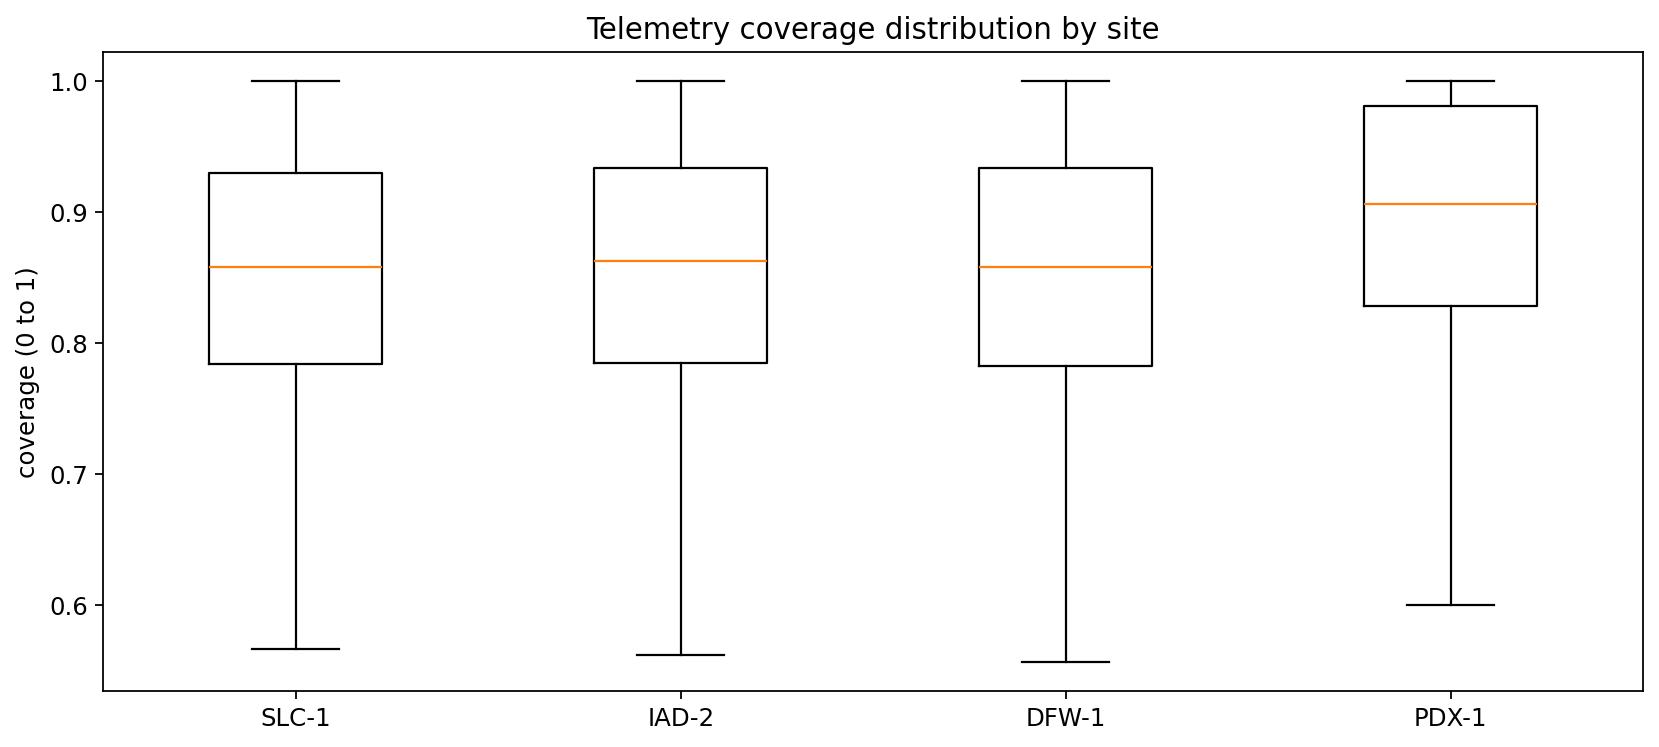

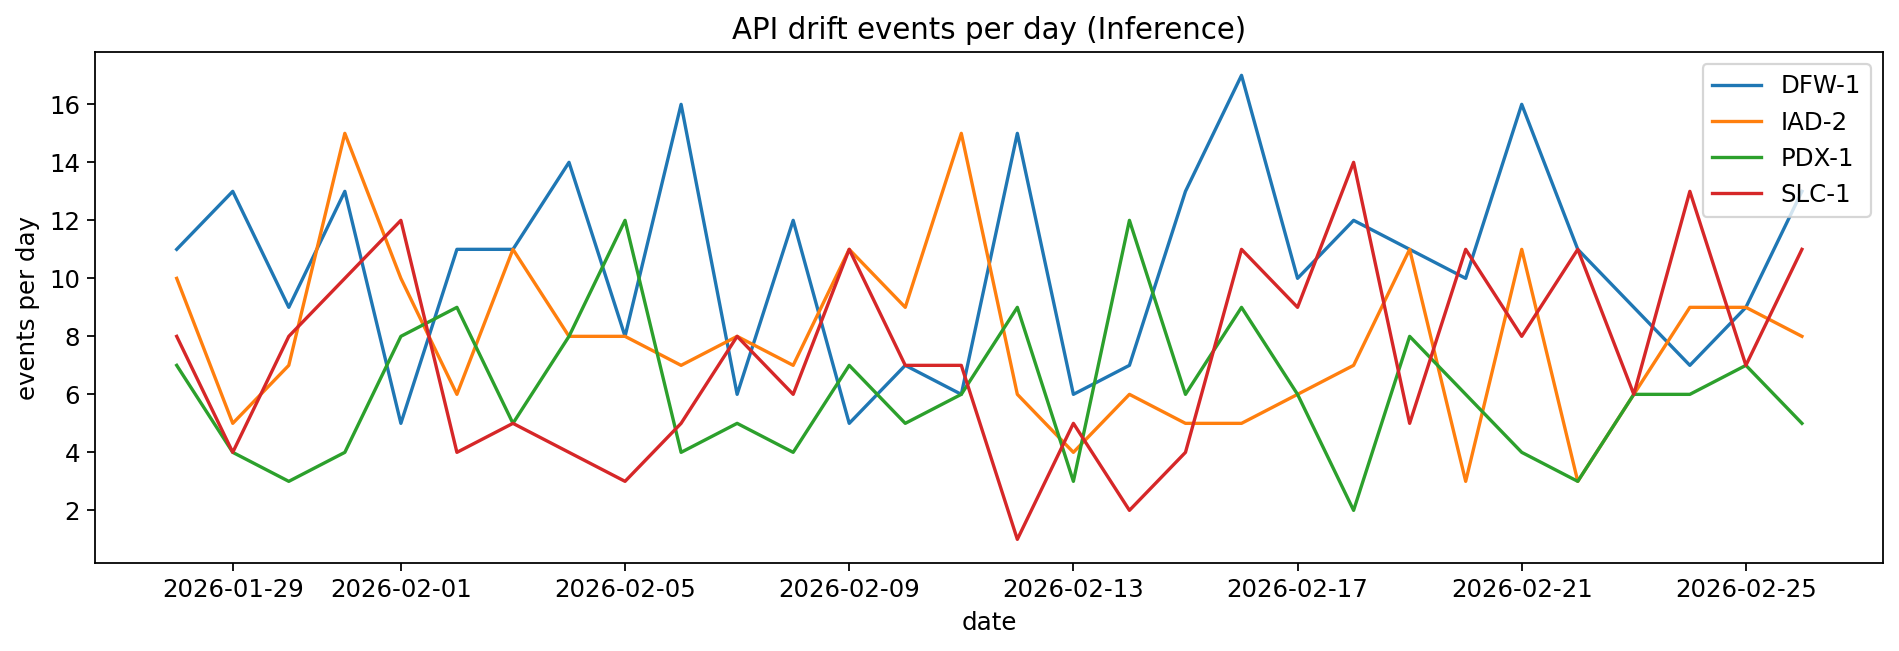

(     site   workload  tele_p10  tele_p50  tele_p90
 19  SLC-1   Training  0.632624  0.759459  0.894935
 9   IAD-2   Training  0.632740  0.760739  0.890196
 4   DFW-1   Training  0.633725  0.754455  0.885640
 14  PDX-1   Training  0.671854  0.806746  0.937999
 6   IAD-2  Inference  0.744409  0.877144  1.000000
 1   DFW-1  Inference  0.749541  0.877281  0.998536
 18  SLC-1    Storage  0.749541  0.874183  1.000000
 16  SLC-1  Inference  0.750222  0.879031  1.000000
 15  SLC-1        Ads  0.752163  0.881835  1.000000
 7   IAD-2     Search  0.754525  0.890447  1.000000
 17  SLC-1     Search  0.754692  0.879097  1.000000
 2   DFW-1     Search  0.754862  0.880971  1.000000,
      site   workload  migration_windows  avg_migration_events  \
 5   IAD-2        Ads                 64              1.015625   
 11  PDX-1  Inference                 71              1.014085   
 8   IAD-2    Storage                 53              1.037736   
 1   DFW-1  Inference                 72              1.013

In [8]:

dfm["date"] = dfm["time_utc"].dt.date

tele = dfm.groupby(["site","workload"], as_index=False).agg(
    tele_p10=("telemetry_coverage", lambda x: float(np.quantile(x, 0.10))),
    tele_p50=("telemetry_coverage", "median"),
    tele_p90=("telemetry_coverage", lambda x: float(np.quantile(x, 0.90))),
)

drift_daily = dfm.groupby(["site","workload","date"], as_index=False)["api_drift_events"].sum()

mig = dfm[dfm["migration_events"] > 0].copy()
mig_agg = mig.groupby(["site","workload"], as_index=False).agg(
    migration_windows=("migration_events","count"),
    avg_migration_events=("migration_events","mean"),
    p95_delta_median=("migration_p95_delta_ms","median"),
)

plt.figure(figsize=(10.5,4.8))
plt.boxplot([dfm.loc[dfm["site"]==s, "telemetry_coverage"].values for s in dfm["site"].unique()],
            labels=list(dfm["site"].unique()), showfliers=False)
plt.title("Telemetry coverage distribution by site")
plt.ylabel("coverage (0 to 1)")
plt.tight_layout()
plt.show()

inf = drift_daily[drift_daily["workload"]=="Inference"].copy()
if not inf.empty:
    plt.figure(figsize=(12,4.2))
    for s in sorted(inf["site"].unique()):
        tmp = inf[inf["site"]==s].sort_values("date")
        plt.plot(tmp["date"], tmp["api_drift_events"], label=s)
    plt.title("API drift events per day (Inference)")
    plt.ylabel("events per day")
    plt.xlabel("date")
    plt.legend()
    plt.tight_layout()
    plt.show()

tele.sort_values("tele_p10").head(12), mig_agg.sort_values("p95_delta_median", ascending=False).head(12)



## 8. Mitigation protocols

Protocols below are framed as decision rules tied to observed metrics.

Power and thermal stabilization

- If throttling_rate rises above threshold and correlates with p95_ms spikes:
  - rebalance placement to reduce hotspot concentration
  - apply thermal aware scheduling for accelerators
  - audit airflow and containment, then cooling setpoints

- If power_capping_rate stays elevated:
  - apply per workload power budgets with priority tiers
  - enforce admission control for low priority traffic
  - schedule batch jobs away from local peak windows

Carbon and grid impact reduction

- If carbon_g_per_kwh is high during load peaks and CO2e per request rises:
  - shift batch and training to lower carbon windows
  - implement carbon aware routing across sites
  - quantify marginal abatement cost per protocol and sequence the cheapest first

Interoperability hardening

- If telemetry coverage is low or variable:
  - standardize OpenTelemetry instrumentation and semantic conventions
  - require minimum coverage before scaling a workload footprint

- If drift events rise or migration deltas are consistently positive:
  - gate releases on conformance tests and interface contract versions
  - run canary migrations with rollback triggers tied to SLO deltas


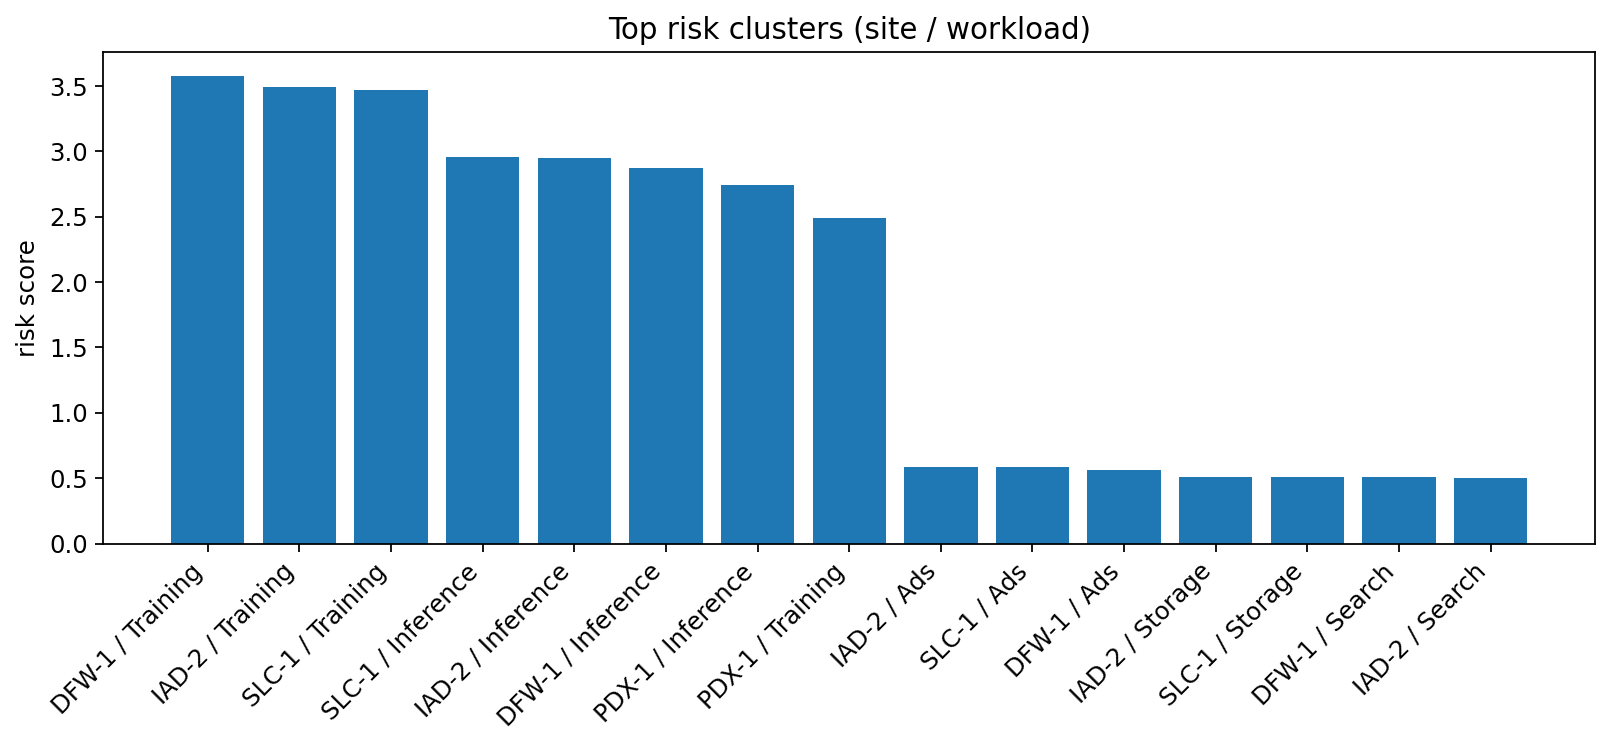

,site,workload,throttle_rate,cap_rate,co2_rate,low_telemetry_rate,slo_ok_rate,median_pue,median_jpr,risk_score
4,DFW-1,Training,0.820833,0.111806,1.0,0.677778,0.718750,1.350756,9740.219751,3.579861
9,IAD-2,Training,0.810417,0.112500,1.0,0.653472,0.737500,1.298105,9407.568120,3.494097
19,SLC-1,Training,0.801389,0.121528,1.0,0.646528,0.745833,1.219687,8793.605235,3.466319
16,SLC-1,Inference,0.421528,0.115972,0.0,0.192361,0.215972,1.219518,118.515674,2.958681
6,IAD-2,Inference,0.434028,0.115278,0.0,0.219444,0.238889,1.299547,126.037769,2.946181
1,DFW-1,Inference,0.411111,0.111806,0.0,0.223611,0.255556,1.349447,130.737414,2.869097
11,PDX-1,Inference,0.411806,0.113889,0.0,0.100694,0.257639,1.179617,114.402068,2.745139
14,PDX-1,Training,0.800000,0.120833,0.0,0.474306,0.747222,1.181099,8532.465360,2.487500
5,IAD-2,Ads,0.006944,0.127778,0.0,0.190972,0.922917,1.301378,42.775289,0.585764
15,SLC-1,Ads,0.004861,0.126389,0.0,0.201389,0.925694,1.220881,40.077337,0.584028


In [9]:

THROTTLE_ALERT = 0.12
POWER_CAP_ALERT = 0.10
CO2_G_PER_REQ_ALERT = float(np.quantile(dfm["co2e_g_per_request"], 0.85))
TELE_COVER_ALERT = 0.80

alerts = dfm.assign(
    throttle_alert=dfm["throttling_rate"] > THROTTLE_ALERT,
    cap_alert=dfm["power_capping_rate"] > POWER_CAP_ALERT,
    co2_alert=dfm["co2e_g_per_request"] > CO2_G_PER_REQ_ALERT,
    telemetry_alert=dfm["telemetry_coverage"] < TELE_COVER_ALERT,
)

alert_summary = alerts.groupby(["site","workload"], as_index=False).agg(
    throttle_rate=("throttle_alert","mean"),
    cap_rate=("cap_alert","mean"),
    co2_rate=("co2_alert","mean"),
    low_telemetry_rate=("telemetry_alert","mean"),
    slo_ok_rate=("slo_ok","mean"),
    median_pue=("pue","median"),
    median_jpr=("joules_per_request","median"),
)

alert_summary["risk_score"] = (
    2.5*(1 - alert_summary["slo_ok_rate"])
    + 1.5*alert_summary["throttle_rate"]
    + 1.5*alert_summary["cap_rate"]
    + 1.0*alert_summary["low_telemetry_rate"]
    + 0.8*alert_summary["co2_rate"]
)

top_risks = alert_summary.sort_values("risk_score", ascending=False).head(15)

plt.figure(figsize=(10.2,4.8))
plt.bar(top_risks["site"] + " / " + top_risks["workload"], top_risks["risk_score"])
plt.xticks(rotation=45, ha="right")
plt.title("Top risk clusters (site / workload)")
plt.ylabel("risk score")
plt.tight_layout()
plt.show()

top_risks



## 9. Scenario analysis: demand response and carbon aware scheduling

We simulate a simple protocol:

- identify windows with high carbon intensity  
- shift a fraction of shiftable workload energy to lower carbon windows  
- observe CO2e reduction

This is a functional demonstration of a policy loop. A production scheduler would also consider deadlines, preemption cost, locality, and compliance constraints.


In [10]:

SHIFTABLE = {"Training", "Storage"}

fleet_wl = dfm.groupby(["time_utc","workload"], as_index=False).agg(
    facility_kwh=("facility_kwh","sum"),
    carbon_g_per_kwh=("carbon_g_per_kwh", lambda x: float(np.average(x, weights=dfm.loc[x.index, "facility_kwh"]))),
)

fleet_wl["co2e_kg"] = fleet_wl["facility_kwh"] * (fleet_wl["carbon_g_per_kwh"] / 1000.0)

thr = float(np.quantile(fleet_wl["carbon_g_per_kwh"], 0.85))
high_mask = fleet_wl["carbon_g_per_kwh"] >= thr

SHIFT_FRAC = 0.20
sim = fleet_wl.copy()
sim["shiftable"] = sim["workload"].isin(SHIFTABLE)

to_move = sim.loc[high_mask & sim["shiftable"], "facility_kwh"].sum() * SHIFT_FRAC
sim.loc[high_mask & sim["shiftable"], "facility_kwh"] *= (1 - SHIFT_FRAC)

low_mask = (~high_mask) & sim["shiftable"]
low_total = sim.loc[low_mask, "facility_kwh"].sum()
if low_total > 0:
    sim.loc[low_mask, "facility_kwh"] += sim.loc[low_mask, "facility_kwh"] / low_total * to_move

sim["co2e_kg"] = sim["facility_kwh"] * (sim["carbon_g_per_kwh"] / 1000.0)

baseline_co2 = float(fleet_wl["co2e_kg"].sum())
shifted_co2 = float(sim["co2e_kg"].sum())
reduction_pct = 100.0 * (baseline_co2 - shifted_co2) / baseline_co2

baseline_co2, shifted_co2, reduction_pct


(10148928.189442532, 10135862.854578974, 0.12873610513029035)

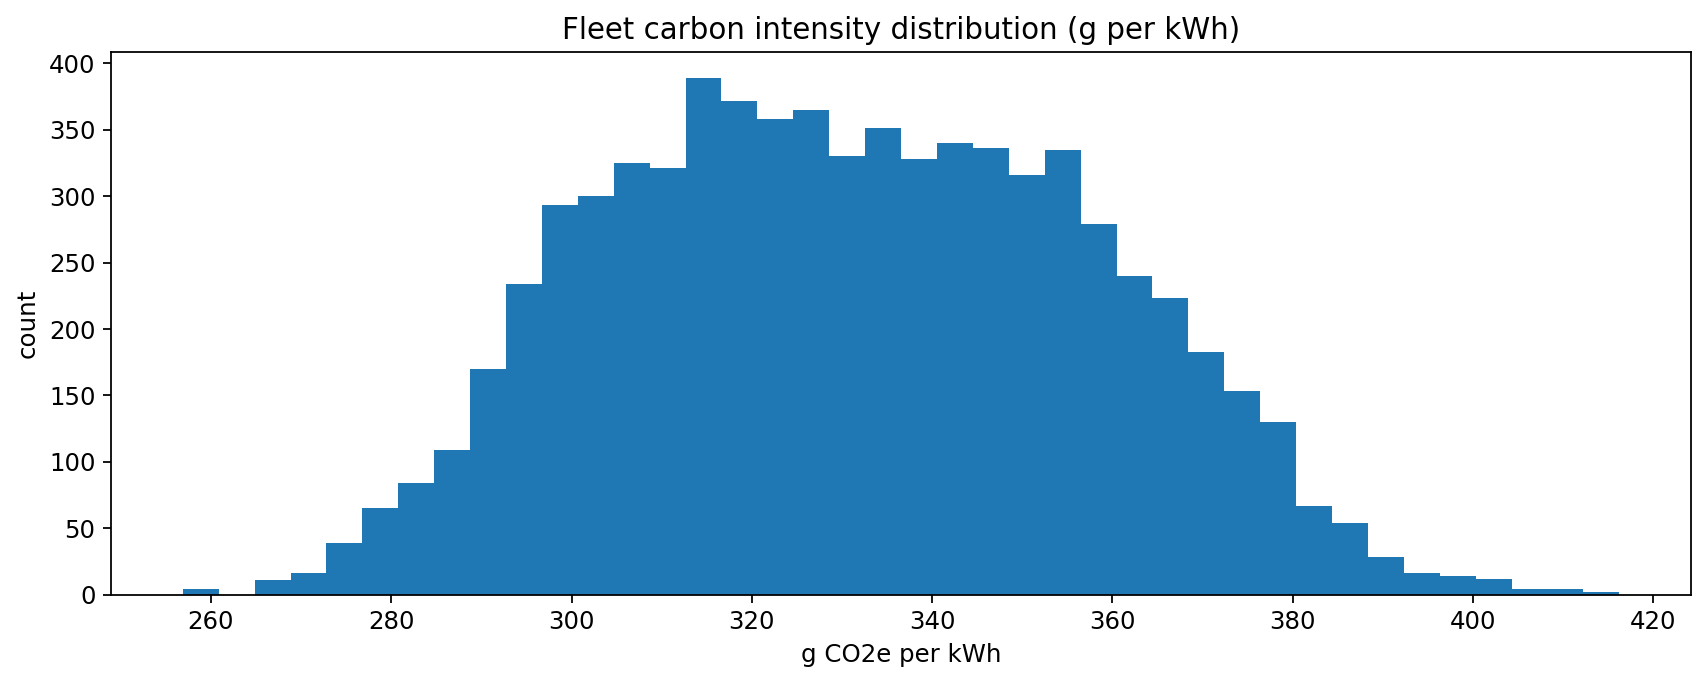

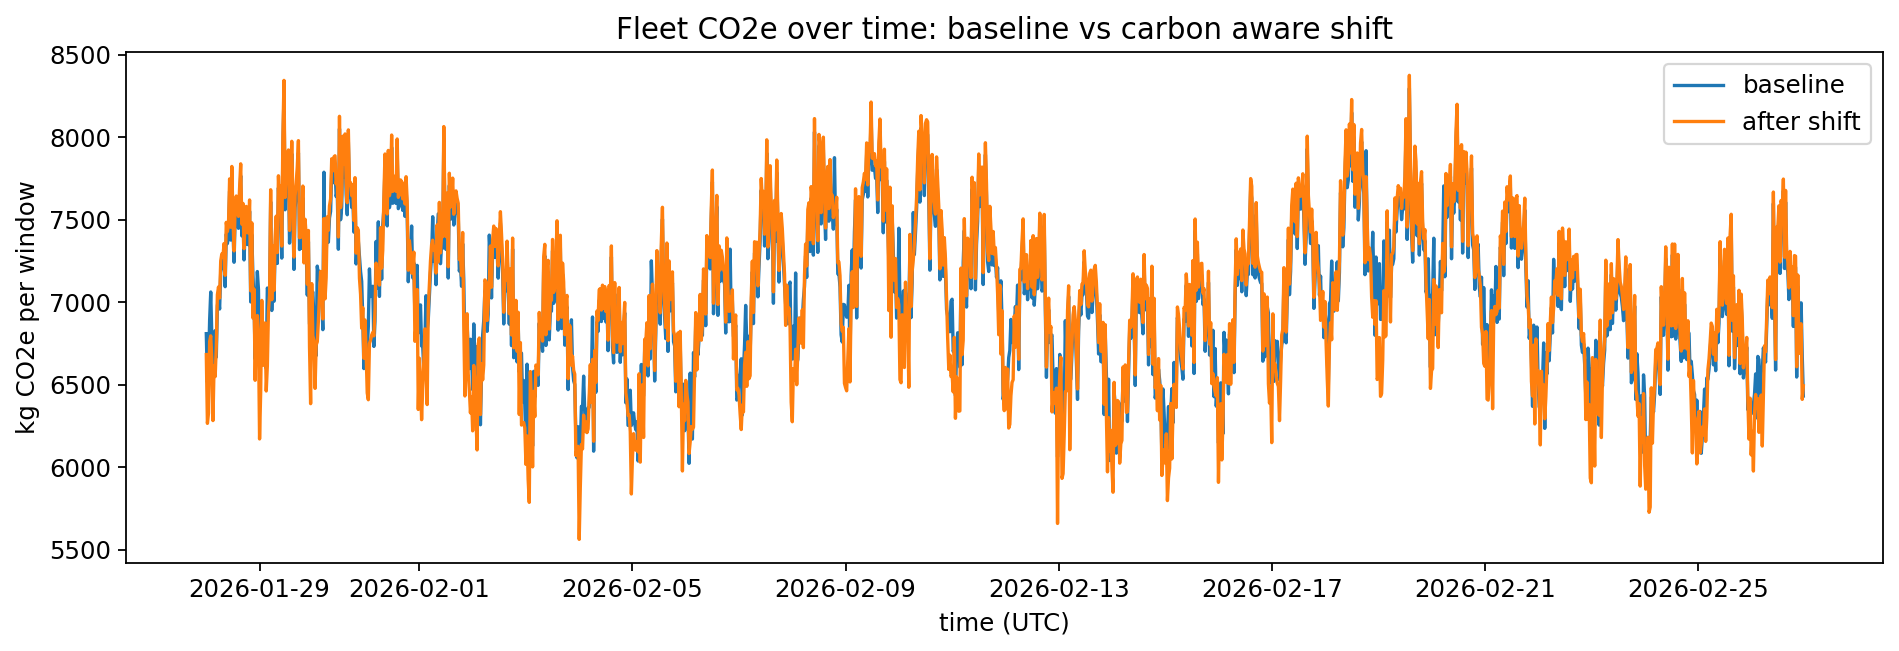

In [11]:

plt.figure(figsize=(10.8,4.4))
plt.hist(fleet_wl["carbon_g_per_kwh"], bins=40)
plt.title("Fleet carbon intensity distribution (g per kWh)")
plt.xlabel("g CO2e per kWh")
plt.ylabel("count")
plt.tight_layout()
plt.show()

base_ts = fleet_wl.groupby("time_utc", as_index=False)["co2e_kg"].sum().rename(columns={"co2e_kg":"baseline_kg"})
sim_ts = sim.groupby("time_utc", as_index=False)["co2e_kg"].sum().rename(columns={"co2e_kg":"shifted_kg"})
merged = base_ts.merge(sim_ts, on="time_utc", how="inner")

plt.figure(figsize=(12,4.2))
plt.plot(merged["time_utc"], merged["baseline_kg"], label="baseline")
plt.plot(merged["time_utc"], merged["shifted_kg"], label="after shift")
plt.title("Fleet CO2e over time: baseline vs carbon aware shift")
plt.ylabel("kg CO2e per window")
plt.xlabel("time (UTC)")
plt.legend()
plt.tight_layout()
plt.show()



## 10. Reporting and export

We export:

- a site KPI table  
- a top risk table  
- a compact run artifact JSON with key results  

These artifacts can be ingested by dashboards or attached to incident reviews.


In [12]:

from pathlib import Path

out_dir = Path("./runs") / "dascient_datacenter_interop_energy"
out_dir.mkdir(parents=True, exist_ok=True)

kpi_site = dfm.groupby("site", as_index=False).agg(
    it_kwh=("it_kwh","sum"),
    facility_kwh=("facility_kwh","sum"),
    co2e_kg=("co2e_kg","sum"),
    water_l=("water_l","sum"),
    pue=("pue", "median"),
    joules_per_request=("joules_per_request","median"),
    co2e_g_per_request=("co2e_g_per_request","median"),
    slo_ok_rate=("slo_ok","mean"),
    telemetry_p10=("telemetry_coverage", lambda x: float(np.quantile(x, 0.10))),
)

kpi_site["cue_kg_per_it_kwh"] = kpi_site["co2e_kg"] / np.maximum(kpi_site["it_kwh"], 1e-9)
kpi_site["wue_l_per_it_kwh"] = kpi_site["water_l"] / np.maximum(kpi_site["it_kwh"], 1e-9)

kpi_path = out_dir / "site_kpis.csv"
risk_path = out_dir / "top_risks.csv"

kpi_site.to_csv(kpi_path, index=False)
top_risks.to_csv(risk_path, index=False)

run_artifact = {
    "ts_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "n_rows": int(len(dfm)),
    "sites": sorted(dfm["site"].unique().tolist()),
    "workloads": sorted(dfm["workload"].unique().tolist()),
    "baseline_co2e_kg": baseline_co2,
    "shifted_co2e_kg": shifted_co2,
    "co2e_reduction_pct": reduction_pct,
    "pue_median": float(dfm["pue"].median()),
    "co2e_g_per_request_p50": float(dfm["co2e_g_per_request"].median()),
    "joules_per_request_p50": float(dfm["joules_per_request"].median()),
}

artifact_path = out_dir / "run_artifact.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(run_artifact, f, indent=2, sort_keys=True)

kpi_path.as_posix(), risk_path.as_posix(), artifact_path.as_posix(), run_artifact


('runs/dascient_datacenter_interop_energy/site_kpis.csv',
 'runs/dascient_datacenter_interop_energy/top_risks.csv',
 'runs/dascient_datacenter_interop_energy/run_artifact.json',
 {'ts_utc': '2026-02-27T16:21:01Z',
  'n_rows': 28800,
  'sites': ['DFW-1', 'IAD-2', 'PDX-1', 'SLC-1'],
  'workloads': ['Ads', 'Inference', 'Search', 'Storage', 'Training'],
  'baseline_co2e_kg': 10148928.189442532,
  'shifted_co2e_kg': 10135862.854578974,
  'co2e_reduction_pct': 0.12873610513029035,
  'pue_median': 1.2537613919858779,
  'co2e_g_per_request_p50': 0.01018886130389976,
  'joules_per_request_p50': 122.08996307141356})


## Closing

This notebook connects:

- interoperability signals to drift and migration risk  
- thermal and power constraints to SLO regressions  
- energy and carbon metrics to scheduling protocols  

To use this with real telemetry:

1. replace the synthetic generator with ingestion  
2. validate units and sampling cadence  
3. tune thresholds with historical baselines  
4. wire exports into dashboards and alerts  
5. attach playbooks to change management and on call

DaScient
